# Fashion Product Adoption Experiments

## 1. Research Question

How do influencer position and social influence strength affect the adoption of a new fashion product within a consumer social network?



## 2. Model Design and Parameters


### 2.1 Model Overview

The model represents the diffusion of a new fashion product through a consumer social network. Each node represents a consumer and each edge represents a social connection between two consumers.

At the beginning of the simulation, one consumer is selected as the influencer and is treated as the initial adopter of the product. Other consumers may subsequently purchase the product based on their individual baseline purchase probability and the purchasing behaviour of their neighbours.

At each simulation step, the purchase probability of consumer \($i$\) is calculated as:


$P_i(t)$ = $\min$(1, $p_i$ + $\alpha$ $F_i(t)$)


where:

- \($p_i$\) is the individual baseline purchase probability of consumer \($i$\);
- \($\alpha$\) is the social influence strength; and
- \($F_i(t)$\) is the fraction of consumer \($i$\)'s neighbours who have purchased the product at time \($t$\).

The simulation continues until all consumers have purchased the product or the maximum number of simulation steps is reached.

During each simulation step, purchase decisions are evaluated for all consumers who have not yet purchased the product. All decisions are based on the network state at the beginning of the step, and new purchases are applied after all consumers have been evaluated. This synchronous update prevents the processing order of consumers from affecting adoption within the same simulation step.

### 2.2 Network Model

A Barabási–Albert preferential attachment network is used to represent the consumer social network. Each node represents a consumer, while each edge represents a social connection through which social influence may occur.

The Barabási–Albert model was selected because it produces heterogeneous node degrees, including a small number of highly connected nodes. This property is useful for this study because the research question investigates whether the position of an influencer within the network affects product adoption.

#### Comparison of Candidate Network Models
| Network | Basic idea | Fit for our project |
|---|---|---|
| Erdős–Rényi random | Connections form randomly with similar opportunity | Usable, but less natural for studying influential hubs |
| Watts–Strogatz small-world | Strong local connections + some long-distance links | Interesting for social communities |
| **Barabási–Albert** | Some nodes become highly connected hubs | **Selected: provides heterogeneous node degrees suitable for comparing influencer positions** |

The network is defined by two parameters: \($n$\), the total number of consumers, and \($m$\), the number of edges created by each new node when it joins the network. In the current model, \($n$=100\) and \($m$=3\).

### 2.3 Influencer Position

Two influencer-position strategies are considered:

- **Central influencer:** the consumer with the highest degree in the network.
- **Less-central influencer:** a consumer located approximately at the 25th percentile of the degree ranking.

Degree represents the number of direct social connections a consumer has. The central strategy therefore places the influencer at a highly connected node, while the less-central strategy represents an influencer with fewer direct connections.

### 2.4 Customer Purchase Behaviour

Each consumer is assigned an individual baseline purchase probability \($p_i$\) during initialisation. The baseline probability represents the consumer's tendency to purchase the product independently of social influence. In the current model, \($p_i$\) is independently sampled from a uniform distribution between 0.01 and 0.10.

The baseline probability is assigned once at the beginning of a simulation and remains unchanged throughout that simulation.

During each simulation step, consumers who have not yet purchased the product may adopt it. Their purchase probability increases according to the proportion of their neighbours who have already purchased the product. Once a consumer purchases the product, the purchase is irreversible.

### 2.5 Social Influence Strength

Social influence strength, \($\alpha$\), controls how strongly the purchasing behaviour of neighbouring consumers affects a consumer's purchase probability.

A larger value of \($\alpha$\) means that consumers are more responsive to neighbours who have already purchased the product.

For example, if 40% of a consumer's neighbours have purchased the product:

\[
$F_i(t)$ = 0.4
\]

with \($\alpha$ = 0.5\), the contribution from social influence is:

\[
0.5 $\times$ 0.4 = 0.2
\]

This value is added to the consumer's individual baseline purchase probability.

### 2.6 Model Parameters

| Parameter | Symbol/code | Current value | Role |
|---|---|---:|---|
| Number of consumers | $N$ | 100 | Fixed parameter |
| Edges per new node | \$m$ | 3 | Fixed parameter |
| Baseline probability | $p_i$ | $U$(0.01,0.10) | Customer attribute |
| Influencer position | `influencer_strategy` | central / less-central | **Independent variable** |
| Social influence | $\alpha$ | TBD | **Independent variable** |
| Maximum steps | $T$ | 50 | Fixed parameter |
| Final adoption rate | — | Measured | **Dependent variable** |
| Adoption speed | — | Measured | **Dependent variable** |

### 2.7 Model Assumptions

- The consumer network contains 100 consumers throughout the experiments. The network size is fixed so that the effects of influencer position and social influence strength can be compared under the same network size.
- The Barabási–Albert network uses \($m$=3\), meaning that each new node forms three connections when it is added to the network. This value is fixed throughout the main experiments to control network connectivity.
  - We are not claiming 100 and 3 represent the real world exactly. We hold them constant because they are not the variables being investigated, and we later check whether our conclusions depend heavily on these choices.
- At \($t$=0\), only the selected influencer has purchased.
- All other customers start with purchased = False.
- Each ordinary customer has an individual baseline purchase probability, assigned once at initialization.
- That baseline stays fixed during one simulation run.
- Customers can later purchase either because of their baseline tendency or because neighbours have purchased.
- Purchase is irreversible: once a consumer purchases the product, they remain an adopter for the remainder of the simulation.
- All purchase decisions within a simulation step are based on the network state at the beginning of that step.
- The social network remains fixed throughout each simulation.

## 3. Baseline Simulation




### 3.1 Initialisation

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx

project_root = Path.cwd().parent
sys.path.append(str(project_root))

from src.model import (
    create_network,
    select_influencer,
    initialise_customers,
    purchase_probability,
    simulation_step,
    run_simulation
)

### 3.2 Get the highest degree customer

In [4]:
G = create_network(100, 3)

print("Number of customers:", G.number_of_nodes())
print("Number of connections:", G.number_of_edges())

degrees = dict(G.degree())

highest_degree_customer = max(
    degrees,
    key=degrees.get
)

print("Highest degree customer:", highest_degree_customer)
print("Degree:", G.degree(highest_degree_customer))

Number of customers: 100
Number of connections: 291
Highest degree customer: 4
Degree: 32


In [ ]:
# Test influencer

central_influencer = select_influencer(
    G,
    "central"
)

less_central_influencer = select_influencer(
    G,
    "less_central"
)

print(
    "Central influencer:",
    central_influencer,
    "Degree:",
    G.degree(central_influencer)
)

print(
    "Less-central influencer:",
    less_central_influencer,
    "Degree:",
    G.degree(less_central_influencer)
)

In [ ]:
# Test function - initial influencer
influencer = select_influencer(G, "central")

initialise_customers(G, influencer)

print("Influencer:", influencer)
print(
    "Influencer purchased:",
    G.nodes[influencer]["purchased"]
)


purchased_customers = [
    customer
    for customer in G.nodes()
    if G.nodes[customer]["purchased"]
]

print("Purchased customers:", purchased_customers)
print("Number purchased:", len(purchased_customers))

Influencer: 4
Influencer purchased: True
Purchased customers: [4]
Number purchased: 1


In [2]:
# Test function - purchase_probability
G = create_network(100, 3)

influencer = select_influencer(G, "central")

initialise_customers(G, influencer)

In [3]:
customer = list(G.neighbors(influencer))[0]

print("Influencer:", influencer)
print("Test customer:", customer)
print("Customer degree:", G.degree(customer))

Influencer: 4
Test customer: 0
Customer degree: 25


In [4]:
probability = purchase_probability(
    G,
    customer,
    social_influence=0.5
)

print("Purchase probability:", probability)

Purchase probability: 0.07


In [27]:
# Test one simulation
G = create_network(100, 3)

influencer = select_influencer(
    G,
    "central"
)

initialise_customers(
    G,
    influencer
)

In [28]:
purchased_before = sum(
    G.nodes[customer]["purchased"]
    for customer in G.nodes()
)

print("Purchased before:", purchased_before)

Purchased before: 1


In [29]:
new_purchases = simulation_step(
    G,
    social_influence=0.5
)

print("New purchases:", new_purchases)
print("Number of new purchases:", len(new_purchases))

New purchases: [9, 16, 34, 42, 66, 68, 72, 74, 75, 90, 96, 97, 98]
Number of new purchases: 13


In [30]:
purchased_after = sum(
    G.nodes[customer]["purchased"]
    for customer in G.nodes()
)

print("Purchased after:", purchased_after)

Purchased after: 14


In [ ]:
# Calculate positions once
pos = nx.spring_layout(G, seed=42)

plt.figure(figsize=(10, 8))

# Draw the whole network
nx.draw(
    G,
    pos,
    node_size=50,
    with_labels=False
)

# Highlight highest-degree customer
nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=[highest_degree_customer],
    node_size=100,
    node_color="red"
)

plt.title("Customer Social Network")
plt.show()

In [32]:
# Test simulation

G, adoption_history = run_simulation(
    num_customers=100,
    edges_per_new_node=3,
    influencer_strategy="central",
    social_influence=0.5,
    max_steps=50
)

print("Adoption history:")
print(adoption_history)

print("Final number purchased:")
print(adoption_history[-1])

Adoption history:
[1, 7, 20, 30, 39, 54, 66, 78, 91, 96, 99, 99, 100]
Final number purchased:
100


In [14]:
final_adoption_rate = (
    adoption_history[-1] / 100
)

print("Final adoption rate:", final_adoption_rate)

Final adoption rate: 1.0


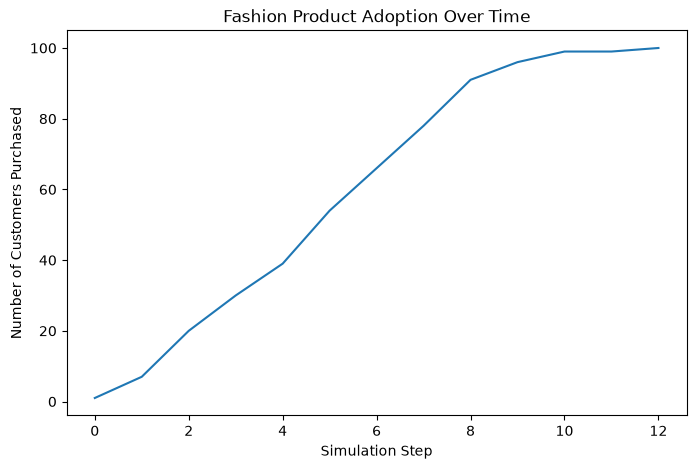

In [33]:
plt.figure(figsize=(8, 5))

plt.plot(adoption_history)

plt.xlabel("Simulation Step")
plt.ylabel("Number of Customers Purchased")
plt.title("Fashion Product Adoption Over Time")

plt.show()

## 4. Experiment 1 — Influencer Strategy

Compare highly central and less-central influencer placement while controlling other model parameters.



## 5. Experiment 2 — Social Influence Strength

Compare different levels of social influence.



## 6. Results

Analyse final adoption rate and adoption speed.



## 7. Discussion

Explain what the results mean and discuss limitations.